In [2]:
pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 2.8 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 3.0 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.3 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=29ce80e4679f5f910dc1e47e9f6a7272e4ede7d6e490e923927b977374c3ee26
  Stored in directory: c:\users\ankur\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successf

In [2]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score


In [3]:
if os.path.exists("nifty50.csv"):
    nifty = pd.read_csv("nifty50.csv", index_col=0)
else:
    nifty = yf.Ticker("^NSEI")
    nifty = nifty.history(period="max")
    nifty.to_csv("nifty50.csv")

nifty.index = pd.to_datetime(nifty.index)

In [4]:
del nifty["Dividends"]
del nifty["Stock Splits"]


nifty["Tomorrow"] = nifty["Close"].shift(-1)


nifty["Target"] = (nifty["Tomorrow"] > nifty["Close"]).astype(int)

In [5]:
nifty["MA20"] = nifty["Close"].rolling(20).mean()
nifty["MA50"] = nifty["Close"].rolling(50).mean()
nifty["RSI"] = 100 - (100/(1 + nifty["Close"].pct_change().rolling(14).mean()))
nifty = nifty.dropna()

In [6]:
predictors = [
    "Close",
    "Volume",
    "Open",
    "High",
    "Low",
    "MA20",
    "MA50",
    "RSI"
]

train = nifty.iloc[:-200]
test = nifty.iloc[-200:]


In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=50,
    random_state=1
)

model.fit(train[predictors], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,50
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)

precision = precision_score(test["Target"], preds)

print("Precision:", precision)

Precision: 0.5441176470588235


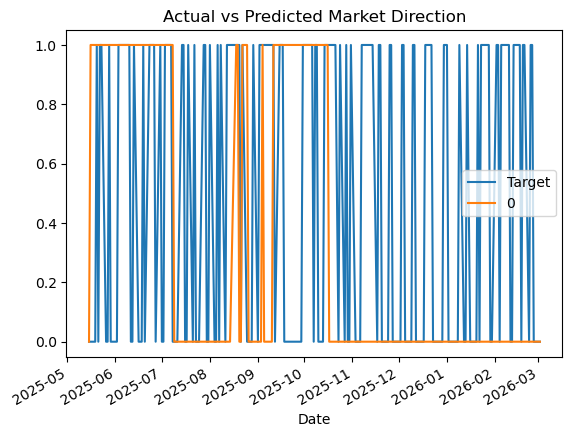

In [9]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()
plt.title("Actual vs Predicted Market Direction")
plt.show()


In [10]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    
    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0
    
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    
    return combined


def backtest(data, model, predictors, start=2000, step=250):
    
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        
        predictions = predict(train, test, predictors, model)
        
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)


predictions = backtest(nifty, model, predictors)

print(predictions["Predictions"].value_counts())

print("Backtest Precision:",
      precision_score(predictions["Target"],
                      predictions["Predictions"]))

Predictions
0.0    2212
1.0     267
Name: count, dtype: int64
Backtest Precision: 0.5580524344569289
